# PE08-2-1

Decision tree and logistic regression analysis on the census income dataset.


In [1]:
import numpy as np
import pandas as pd

from sklearn import metrics, tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import graphviz


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')


In [3]:
df = pd.read_csv('../data/census-income.csv')
df = df.dropna().copy()
df


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,lte50k
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,lte50k
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,lte50k
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,lte50k
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,lte50k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,lte50k
32557,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,gt50k
32558,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,lte50k
32559,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,lte50k


In [4]:
df['Income'] = np.where(df['Income'] == 'lte50k', 0, 1)

dfdummies_workclass = pd.get_dummies(df['workclass'], prefix='workclass', dtype=int)
dfdummies_education = pd.get_dummies(df['education'], prefix='education', dtype=int)
dfdummies_occupation = pd.get_dummies(df['occupation'], prefix='occupation', dtype=int)
dfdummies_race = pd.get_dummies(df['race'], prefix='race', dtype=int)
dfdummies_sex = pd.get_dummies(df['sex'], prefix='sex', dtype=int)

dfactual = pd.concat(
    [
        df['Income'],
        df['age'],
        dfdummies_workclass,
        dfdummies_education,
        dfdummies_occupation,
        dfdummies_race,
        dfdummies_sex,
    ],
    axis=1,
)
dfactual


,Income,age,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
0,0,39,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1,0,50,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
2,0,38,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3,0,53,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
4,0,28,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0,27,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0
32557,1,40,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
32558,0,58,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
32559,0,22,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1


In [5]:
independent_variables = dfactual.drop('Income', axis=1)
x = independent_variables.values
y = dfactual['Income'].values

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    train_size=0.8,
    test_size=0.2,
    shuffle=False,
)

print(f'Training rows: {len(x_train)}')
print(f'Testing rows: {len(x_test)}')
independent_variables.head()


Training rows: 24129
Testing rows: 6033


,age,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
0,39,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1,50,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
2,38,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3,53,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
4,28,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0


In [6]:
print('\n{} Decision Tree {}\n'.format('=' * 20, '=' * 20))

decisionTreeClassifier = tree.DecisionTreeClassifier(
    criterion='gini',
    splitter='best',
    max_depth=5,
    random_state=42,
)
decisionTreeClassifier.fit(x_train, y_train)

dt_y_train_pred = decisionTreeClassifier.predict(x_train)

print('Training Accuracy = {}'.format(metrics.accuracy_score(y_train, dt_y_train_pred)))
print('Training Confusion = \n{}'.format(metrics.confusion_matrix(y_train, dt_y_train_pred, labels=[0, 1])))



==================== Decision Tree ====================

Training Accuracy = 0.7990799452940445
Training Confusion = 
[[16463  1691]
 [ 3157  2818]]


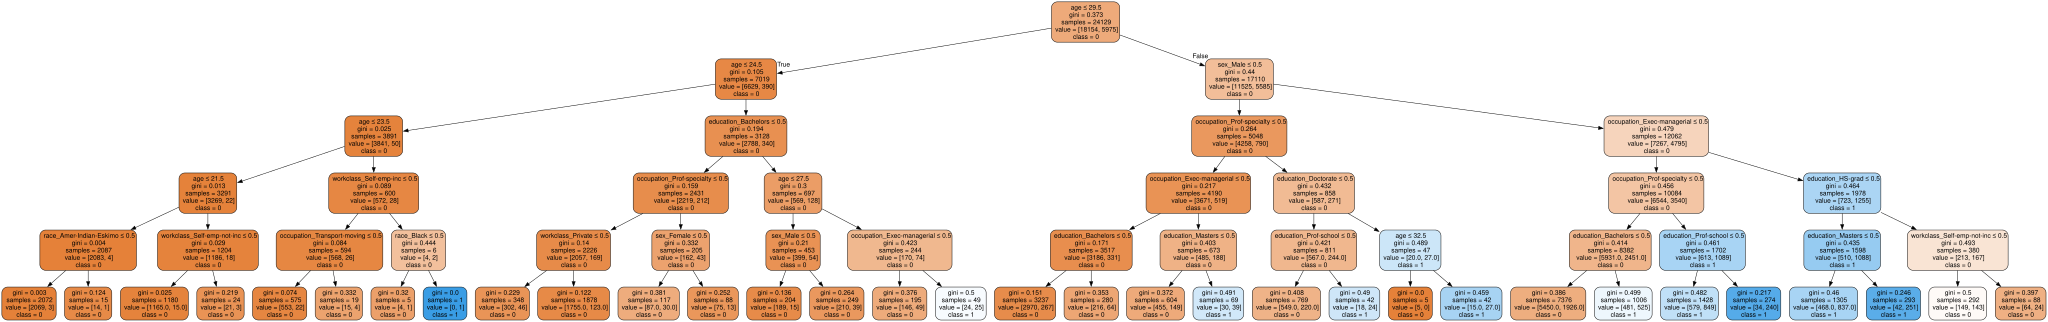

In [7]:
dot_data = tree.export_graphviz(
    decisionTreeClassifier,
    out_file=None,
    feature_names=independent_variables.columns,
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    special_characters=True,
)
graph = graphviz.Source(dot_data)
graph


In [8]:
dt_y_test_pred = decisionTreeClassifier.predict(x_test)

print('Testing Accuracy = {}'.format(metrics.accuracy_score(y_test, dt_y_test_pred)))
print('Testing Confusion = \n{}'.format(metrics.confusion_matrix(y_test, dt_y_test_pred, labels=[0, 1])))
print(classification_report(y_test, dt_y_test_pred))


Testing Accuracy = 0.7926404773744405
Testing Confusion = 
[[4060  440]
 [ 811  722]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      4500
           1       0.62      0.47      0.54      1533

    accuracy                           0.79      6033
   macro avg       0.73      0.69      0.70      6033
weighted avg       0.78      0.79      0.78      6033



In [9]:
print('\n{} Logistic Regression {}\n'.format('=' * 20, '=' * 20))

# Reuse the same train/test split to make the comparison with the decision tree fair.
logisticRegressionClassifier = LogisticRegression(
    max_iter=2000,
    solver='liblinear',
)
logisticRegressionClassifier.fit(x_train, y_train)

lr_y_train_pred = logisticRegressionClassifier.predict(x_train)

print('Training Accuracy = {}'.format(metrics.accuracy_score(y_train, lr_y_train_pred)))
print('Training Confusion = \n{}'.format(metrics.confusion_matrix(y_train, lr_y_train_pred, labels=[0, 1])))



==================== Logistic Regression ====================

Training Accuracy = 0.8027270089933275
Training Confusion = 
[[16906  1248]
 [ 3512  2463]]


In [10]:
lr_y_test_pred = logisticRegressionClassifier.predict(x_test)

print('Testing Accuracy = {}'.format(metrics.accuracy_score(y_test, lr_y_test_pred)))
print('Testing Confusion = \n{}'.format(metrics.confusion_matrix(y_test, lr_y_test_pred, labels=[0, 1])))
print(classification_report(y_test, lr_y_test_pred))


Testing Accuracy = 0.8009282280788994
Testing Confusion = 
[[4201  299]
 [ 902  631]]
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      4500
           1       0.68      0.41      0.51      1533

    accuracy                           0.80      6033
   macro avg       0.75      0.67      0.69      6033
weighted avg       0.79      0.80      0.78      6033



In [11]:
coefficient_df = pd.DataFrame(
    {
        'feature': independent_variables.columns,
        'coefficient': logisticRegressionClassifier.coef_[0],
    }
)
coefficient_df['odds_ratio'] = np.exp(coefficient_df['coefficient'])

top_positive = coefficient_df.sort_values('coefficient', ascending=False).head(10).reset_index(drop=True)
top_negative = coefficient_df.sort_values('coefficient', ascending=True).head(10).reset_index(drop=True)

print('Top positive coefficients:')
display(top_positive)

print('Top negative coefficients:')
display(top_negative)


Top positive coefficients:


,feature,coefficient,odds_ratio
0,education_Prof-school,2.0133,7.4878
1,education_Doctorate,1.9227,6.8394
2,education_Masters,1.3154,3.7264
3,occupation_Exec-managerial,0.9066,2.4758
4,education_Bachelors,0.9064,2.4754
5,occupation_Protective-serv,0.5662,1.7615
6,occupation_Tech-support,0.5597,1.7502
7,occupation_Prof-specialty,0.5373,1.7113
8,education_Assoc-voc,0.4115,1.5090
9,education_Assoc-acdm,0.3977,1.4883


Top negative coefficients:


,feature,coefficient,odds_ratio
0,occupation_Priv-house-serv,-1.7040,0.1819
1,sex_Female,-1.6982,0.1830
2,education_5th-6th,-1.5026,0.2226
3,education_7th-8th,-1.4089,0.2444
4,education_9th,-1.3330,0.2637
5,education_1st-4th,-1.2818,0.2775
6,education_Preschool,-1.2462,0.2876
7,occupation_Other-service,-1.1277,0.3238
8,occupation_Handlers-cleaners,-0.9392,0.3910
9,education_11th,-0.9098,0.4026
